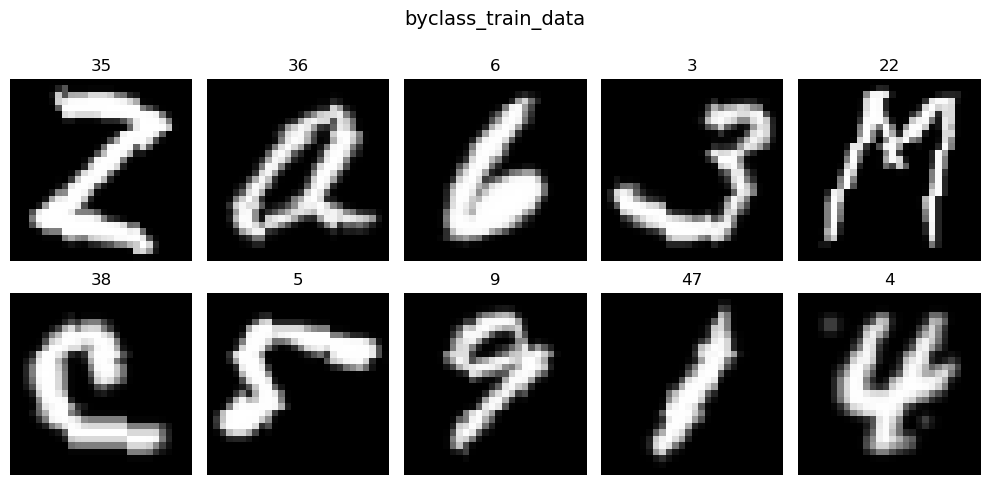

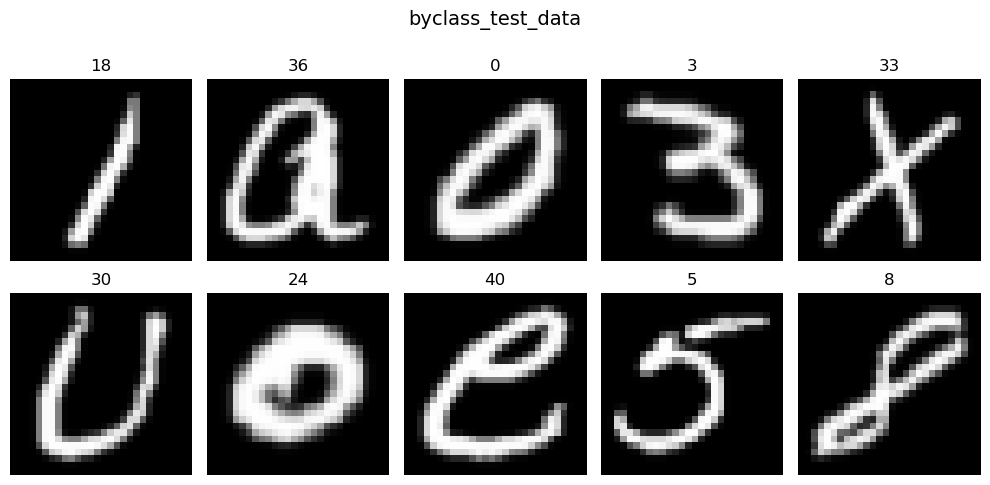

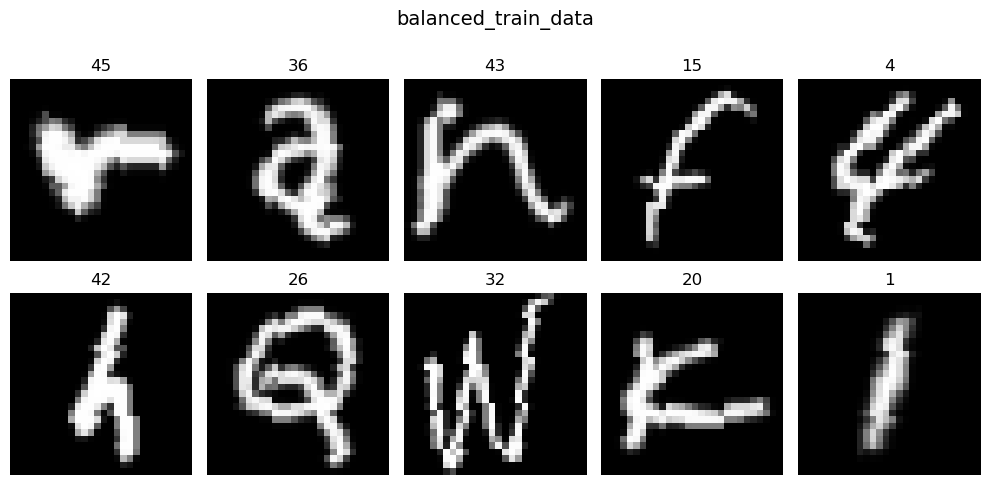

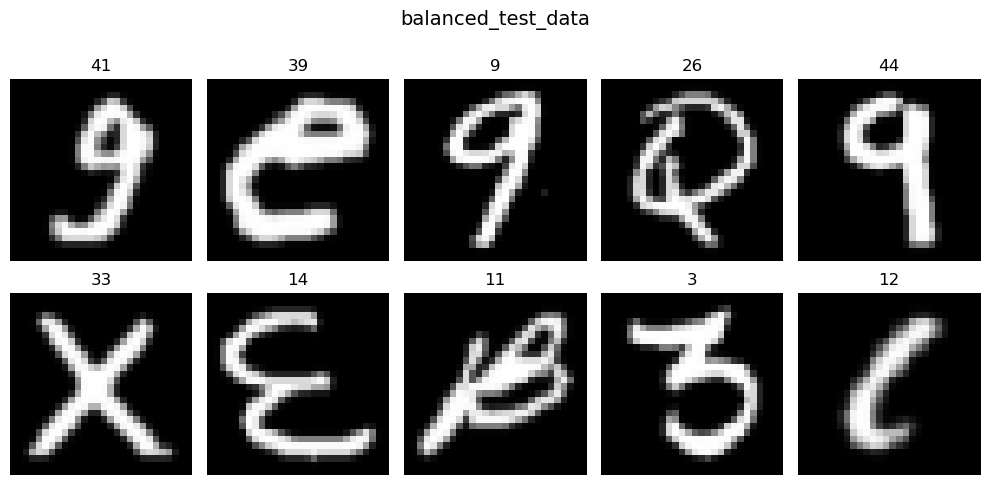

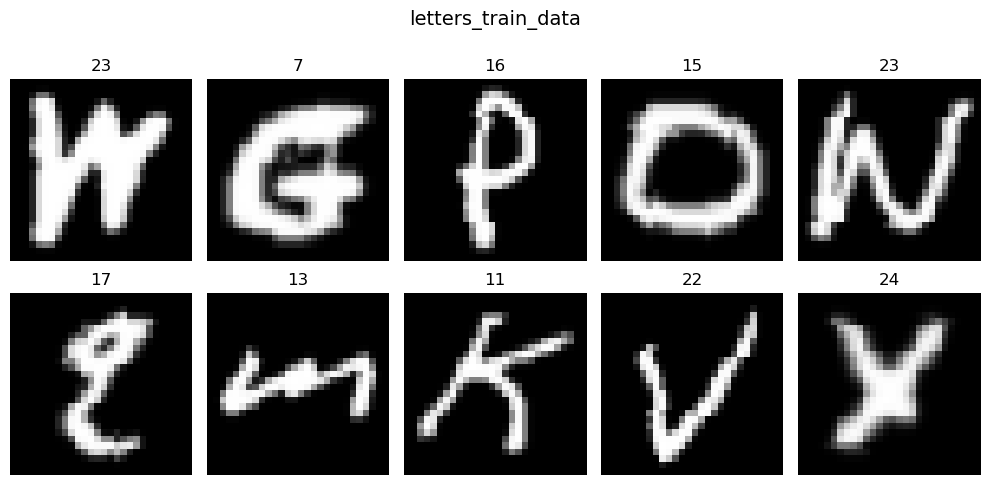

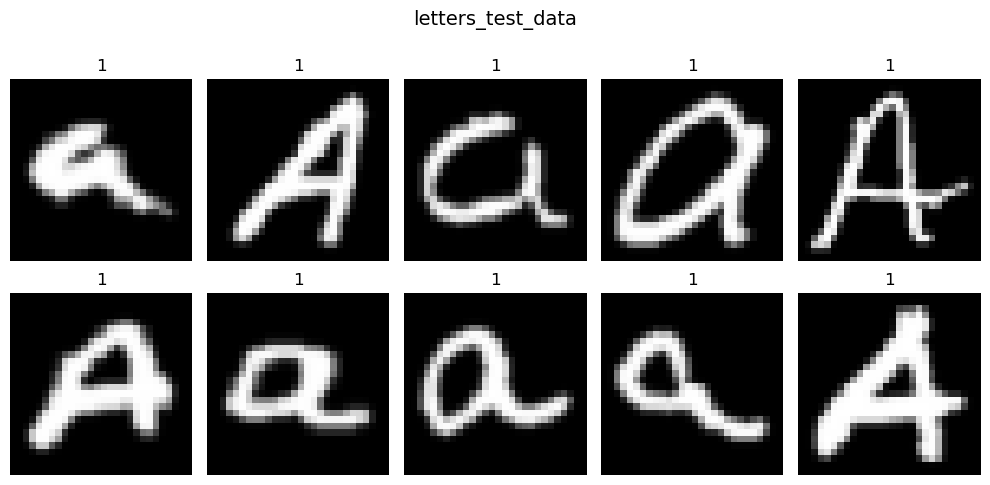

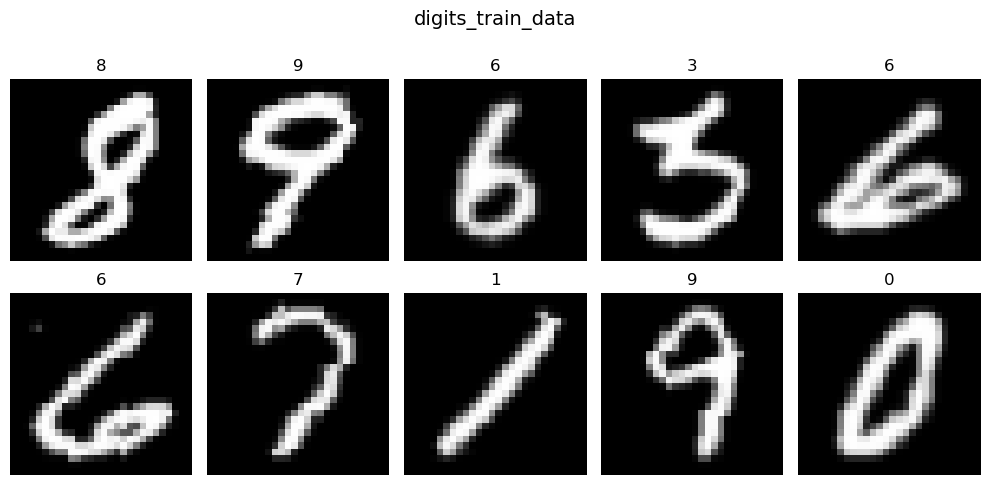

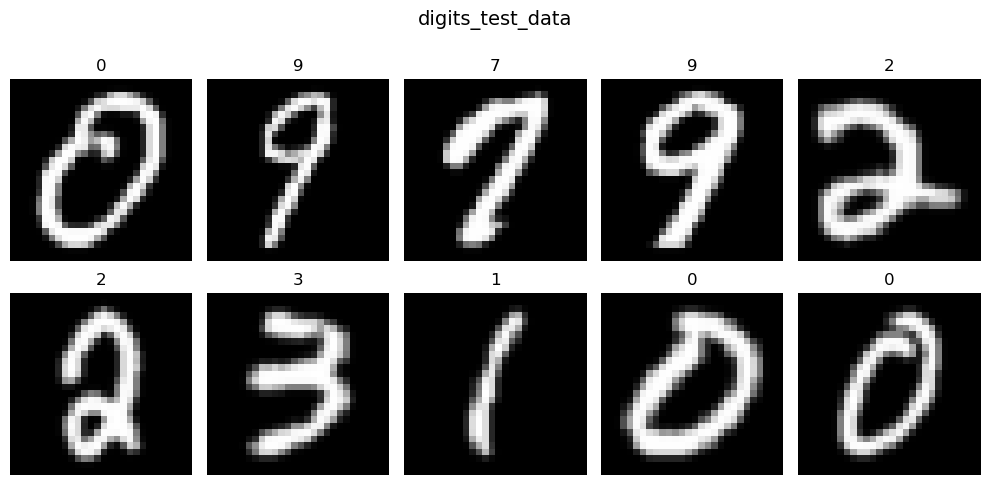

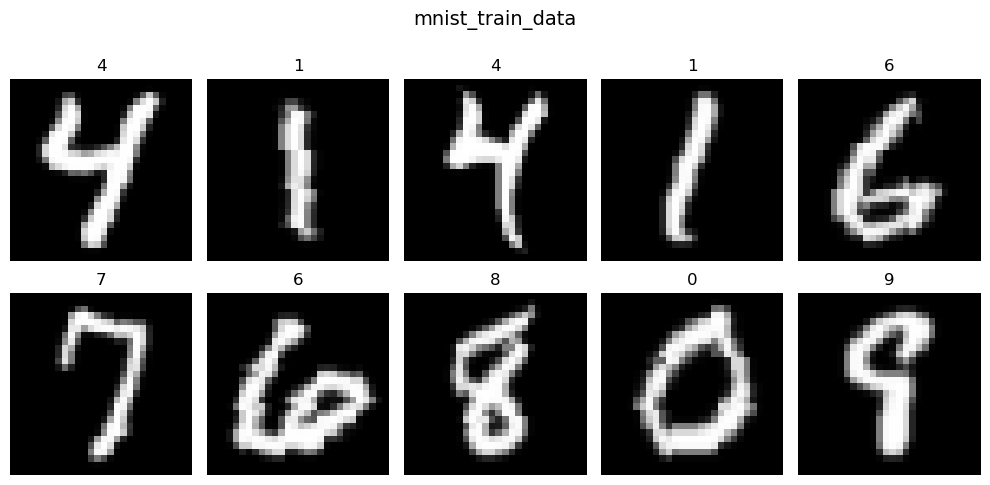

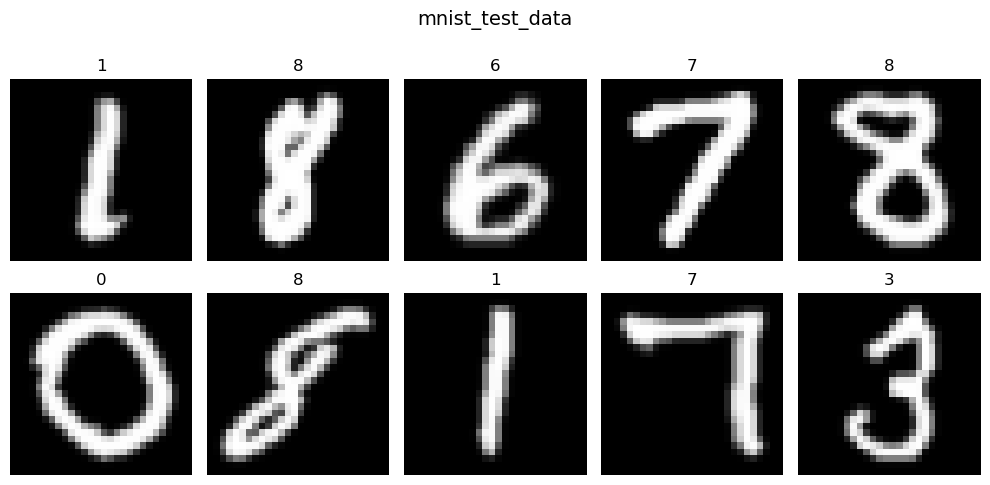

In [ ]:
import torch
from torchvision.datasets import EMNIST
from torchvision.transforms import v2

'''

tran = v2.Compose([v2.RandomHorizontalFlip(p=1.0),
                   v2.RandomRotation(degrees=(90, 90))])

'''

tran_train = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),  
    v2.RandomRotation(degrees=(90, 90)),      
    v2.RandomRotation(degrees=(-10, 10)),     
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),    # [0, 1]
    v2.Normalize(mean=[0.1307], std=[0.3081]) # normalisation MNIST/EMNIST
])

tran_test = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),
    v2.RandomRotation(degrees=(90, 90)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307], std=[0.3081])
])

byclass_train_data = EMNIST(
    root="data",
    split="byclass",
    train=True,
    transform=tran_train
)

byclass_test_data = EMNIST(
    root="data",
    split="byclass",
    train=False,
    transform=tran_test
)

balanced_train_data = EMNIST(
    root="data",
    split="balanced",
    train=True,
    transform=tran_train
)

balanced_test_data = EMNIST(
    root="data",
    split="balanced",
    train=False,
    transform=tran_test
)

letters_train_data = EMNIST(
    root="data",
    split="letters",
    train=True,
    transform=tran_train
)

letters_test_data = EMNIST(
    root="data",
    split="letters",
    train=False,
    transform=tran_test
)

digits_train_data = EMNIST(
    root="data",
    split="digits",
    train=True,
    transform=tran_train
)

digits_test_data = EMNIST(
    root="data",
    split="digits",
    train=False,
    transform=tran_test
)

mnist_train_data = EMNIST(
    root="data",
    split="mnist",
    train=True,
    transform=tran_train
)

mnist_test_data = EMNIST(
    root="data",
    split="mnist",
    train=False,
    transform=tran_test
)

import matplotlib.pyplot as plt

def show_images(data, main_title=None):
    plt.figure(figsize=(10, 5))
    plt.suptitle(t=main_title, y=1.0, fontsize=14)
    for i, (im, lab) in zip(range(1, 11), data):
        plt.subplot(2, 5, i)
        # (1, 28, 28) → (28, 28, 1) puis squeeze → (28, 28)
        plt.imshow(X=im.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.title(label=lab)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    
'''

def show_images(data, main_title=None):
    plt.figure(figsize=(10, 5))
    plt.suptitle(t=main_title, y=1.0, fontsize=14)
    for i, (im, lab) in zip(range(1, 11), data):
        plt.subplot(2, 5, i)
        plt.imshow(X=im)
        plt.title(label=lab)
    plt.tight_layout()
    plt.show()

'''
show_images(data=byclass_train_data, main_title="byclass_train_data")
show_images(data=byclass_test_data, main_title="byclass_test_data")

show_images(data=balanced_train_data, main_title="balanced_train_data")
show_images(data=balanced_test_data, main_title="balanced_test_data")

show_images(data=letters_train_data, main_title="letters_train_data")
show_images(data=letters_test_data, main_title="letters_test_data")

show_images(data=digits_train_data, main_title="digits_train_data")
show_images(data=digits_test_data, main_title="digits_test_data")

show_images(data=mnist_train_data, main_title="mnist_train_data")
show_images(data=mnist_test_data, main_title="mnist_test_data")



In [4]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    byclass_train_data,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    byclass_test_data,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

#modele exemple utilisée : https://zackproser.com/blog/mnist-pytorch-hand-drawn-digit-recognizer
# 1. Create a simple neural net
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv3d(128, 128, kernel_size=3, padding=1)
        self.fc3 = nn.Linear(128, 62)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        return x


# 3. Train the neural network
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

# Test the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f"Accuracy on test set: {100 * correct / total:.2f}%")

# Save the model
torch.save(model.state_dict(), "mnist_model.pth")


In [5]:
import torch
import torch.nn as nn
from torchvision.transforms import v2
from PIL import Image, ImageOps

# --- 1. Recharger le modèle ---
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 62)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN().to(device)
model.load_state_dict(torch.load("mnist_model.pth", map_location=device))
model.eval()

# --- 2. Mapping label → caractère (byclass: 0-9, A-Z, a-z) ---
CLASSES = (
    [str(i) for i in range(10)] +          # 0–9
    [chr(c) for c in range(65, 91)] +       # A–Z
    [chr(c) for c in range(97, 123)]        # a–z
)


In [ ]:
# Affiche les vrais labels du dataset
print(byclass_train_data.classes)       # liste 
print(byclass_train_data.class_to_idx) # dict char → label

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'I': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'O': 24, 'P': 25, 'Q': 26, 'R': 27, 'S': 28, 'T': 29, 'U': 30, 'V': 31, 'W': 32, 'X': 33, 'Y': 34, 'Z': 35, 'a': 36, 'b': 37, 'c': 38, 'd': 39, 'e': 40, 'f': 41, 'g': 42, 'h': 43, 'i': 44, 'j': 45, 'k': 46, 'l': 47, 'm': 48, 'n': 49, 'o': 50, 'p': 51, 'q': 52, 'r': 53, 's': 54, 't': 55, 'u': 56, 'v': 57, 'w': 58, 'x': 59, 'y': 60, 'z': 61}


In [ ]:
from PIL import Image, ImageOps
def predict_letter(image_path: str) -> str:
    img = Image.open(image_path).convert("L")
    img = img.resize((28, 28), resample=Image.LANCZOS)

    tensor = tran_test(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probabilities = torch.softmax(output, dim=1)
        top3_conf, top3_idx = torch.topk(probabilities, 3, dim=1)

    print("Top 3 prédictions :")
    for conf, idx in zip(top3_conf[0], top3_idx[0]):
        print(f"  '{CLASSES[idx.item()]}' — {conf.item()*100:.1f}%")
predict_letter("lettre.png")

Top 3 prédictions :
  'I' — 100.0%
  '1' — 0.0%
  'l' — 0.0%


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (32, 28, 28)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (32, 14, 14)

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (64, 7, 7)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 62)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

    scheduler.step()

# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f"Accuracy on test set: {100 * correct / total:.2f}%")
torch.save(model.state_dict(), "cnn_model.pth")

Epoch 1/10, Batch 0/10906, Loss: 4.2275
Epoch 1/10, Batch 100/10906, Loss: 1.1094
Epoch 1/10, Batch 200/10906, Loss: 1.1630


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
from torchvision.transforms import v2
from PIL import Image, ImageOps

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
model.load_state_dict(torch.load("cnn_model.pth", map_location=device))
model.eval()

# --- 2. Mapping label → caractère (byclass: 0-9, A-Z, a-z) ---
CLASSES = (
    [str(i) for i in range(10)] +          # 0–9
    [chr(c) for c in range(65, 91)] +       # A–Z
    [chr(c) for c in range(97, 123)]        # a–z
)

